# Exploring earthquake events

## Install the GAS Client SDK


In [ ]:
%pip install -q gas-client

In [2]:

from urllib.parse import urljoin
from IPython.display import HTML, Image, display
from gas_client import GasClient

## User settings


In [3]:
from dotenv import load_dotenv
import os
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

server_url = "http://127.0.0.1:4042"
load_dotenv(project_root / ".env")
openai_api_key = os.environ["OPENAI_API_KEY"]
timeout_seconds = 900

client = GasClient(
    server_url,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
    artifact_delivery="URL",
)

credentials = {"OPENAI_API_KEY": openai_api_key}

## Connect to the agents


In [4]:
data_agent = client.agent("geospatial_data_retrieval_agent")
esda_agent = client.agent("exploratory_spatial_data_analysis_agent")


for agent in [data_agent, esda_agent]:
    print(agent.agent_id, agent.status().get("status"))

geospatial_data_retrieval_agent available
exploratory_spatial_data_analysis_agent available


## Helper functions


In [5]:
def absolute_url(url):
    if url.startswith("/"):
        return urljoin(server_url, url)
    return url


def first_artifact_url(task_result, preferred_extensions=None):
    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    preferred_extensions = preferred_extensions or []

    for extension in preferred_extensions:
        for artifact in artifacts:
            url = artifact.get("url")
            filename = artifact.get("filename") or artifact.get("name") or url or ""
            if url and str(filename).lower().endswith(extension.lower()):
                return absolute_url(url)

    for artifact in artifacts:
        if artifact.get("url"):
            return absolute_url(artifact["url"])

    raise RuntimeError("The task returned no artifact URL.")


def display_visual_artifacts(task_result):
    from urllib.request import urlopen

    artifacts = task_result.get("outputs", {}).get("artifacts", [])
    for artifact in artifacts:
        url = artifact.get("url")
        filename = artifact.get("filename") or artifact.get("name") or ""
        if not url:
            continue
        display_url = absolute_url(url)
        lower_name = str(filename).lower()
        if lower_name.endswith((".png", ".jpg", ".jpeg", ".gif")):
            image_format = "jpeg" if lower_name.endswith((".jpg", ".jpeg")) else lower_name.rsplit(".", 1)[-1]
            try:
                with urlopen(display_url, timeout=120) as response:
                    image_bytes = response.read()
                
                display(Image(data=image_bytes, format=image_format))
            except Exception as exc:
                print(f"Could not embed image '{filename}' ({exc}); linking instead.")
                display(HTML(f'<a href="{display_url}" target="_blank">Open image artifact: {filename}</a>'))
        elif lower_name.endswith(".html"):
            display(HTML(f'<a href="{display_url}" target="_blank">Open interactive HTML artifact: {filename}</a>'))
        else:
            display(HTML(f'<a href="{display_url}" target="_blank">Open artifact: {filename}</a>'))


def run_streaming_task(agent, instructions, *, input_datasets=None, parameters=None, title=None):
    if title:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    final_result = None
    for event in agent.execute_task(
        instructions,
        mode="stream",
        input_datasets=input_datasets,
        artifact_delivery="URL",
        credentials=credentials,
        parameters=parameters,
        timeout=timeout_seconds,
    ):
        client.print_stream_event(event)
        if event.get("event") == "task_result":
            final_result = event.get("payload")

    if final_result is None:
        raise RuntimeError("The stream ended before returning a task_result event.")

    client.print_task_summary(final_result)
    return final_result

## 1. Download — data retrieval agent


In [6]:
earthquake_result = run_streaming_task(
    data_agent,
    (
        "Use the USGS Earthquake data source. Download earthquakes from the last 30 days "
        "with magnitude 2.5 or greater for California and nearby areas. Return one GeoJSON "
        "point dataset with event time, magnitude, depth, place/location description, event id, "
        "and geometry. No source API key is required."
    ),
    title="Download recent USGS earthquakes",
)

earthquake_url = first_artifact_url(earthquake_result, preferred_extensions=[".geojson", ".json", ".gpkg"])
earthquake_url


Download recent USGS earthquakes
[19:12:40] stream_connected: Streaming connection established.
[19:12:40] Geospatial Data Retrieval Agent: I received your request.
[19:12:40] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[19:12:40] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[19:12:40] task_accepted: Task accepted. Starting streaming execution.
[19:12:40] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[19:12:40] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[19:12:42] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[19:12:42] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[19:12:42] Geospatial Da

'http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-5735-ufxk-5234.geojson'

## 2. Explore — ESDA agent


In [7]:
esda_result = run_streaming_task(
    esda_agent,
    (
        "Explore the earthquake events. Show the distributions of magnitude and depth, the "
        "correlation between them, and the spatial pattern of magnitude (a point-density map "
        "and global Moran's I)."
    ),
    input_datasets=[earthquake_url],
    title="Explore the earthquake events (ESDA)",
)


Explore the earthquake events (ESDA)
[19:13:07] stream_connected: Streaming connection established.
[19:13:07] Exploratory Spatial Data Analysis Agent: I received your request.
[19:13:07] Exploratory Spatial Data Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[19:13:08] Exploratory Spatial Data Analysis Agent: I found the required credentials and can start the model-backed workflow.
[19:13:08] task_accepted: Task accepted. Starting streaming execution.
[19:13:08] Exploratory Spatial Data Analysis Agent: Next I will run the agent with the prepared inputs.
[19:13:08] Exploratory Spatial Data Analysis Agent: I will profile the dataset(s), generate an ESDA script, execute it, and return an HTML report with charts.
[19:13:08] Exploratory Spatial Data Analysis Agent: I am profiling each dataset — shape, dtypes, missingness, and numeric/categorical/datetime/geometry classification.
[19:13:08] Ex

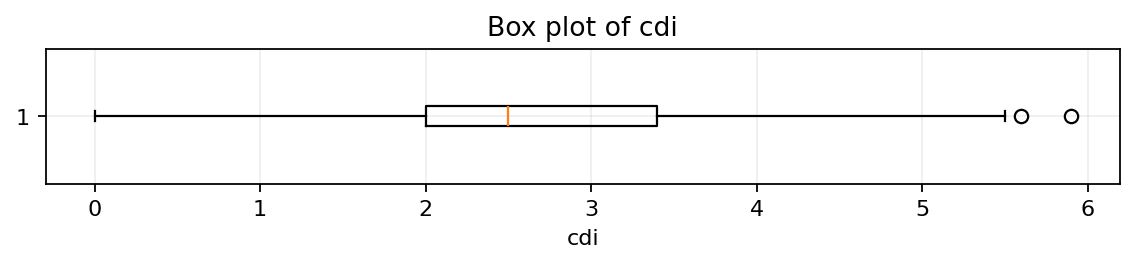

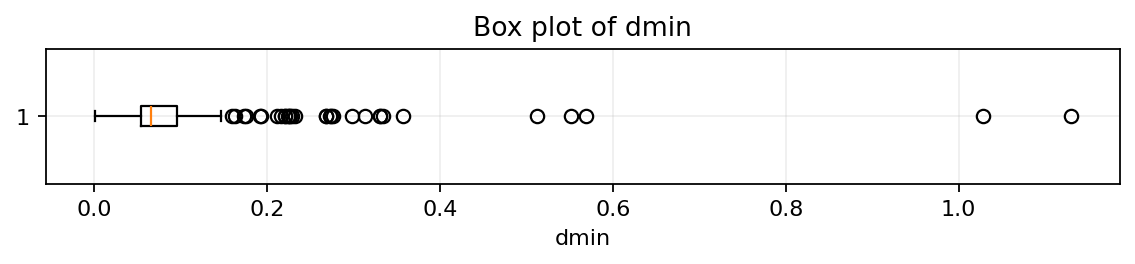

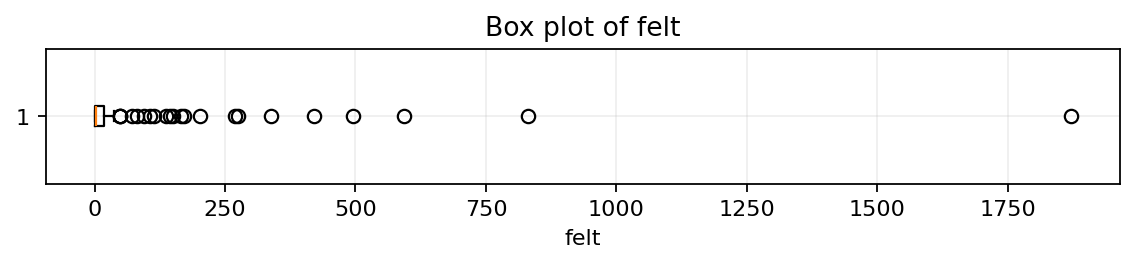

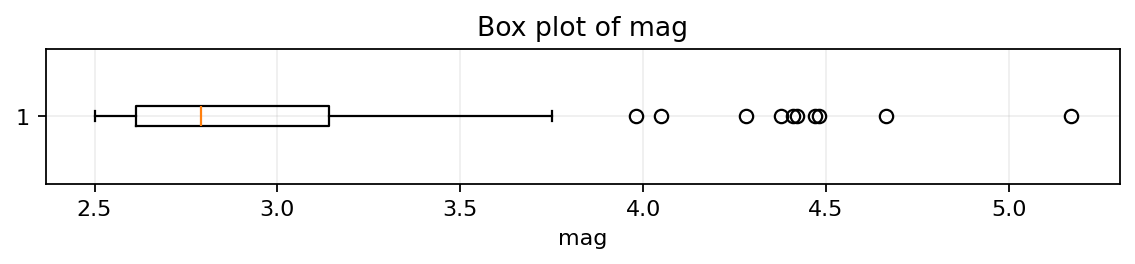

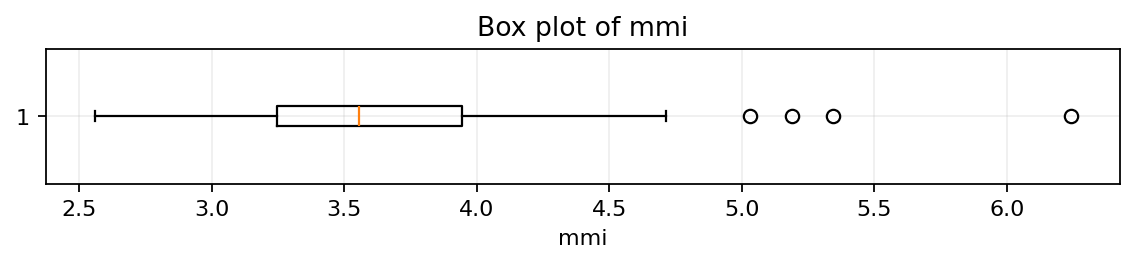

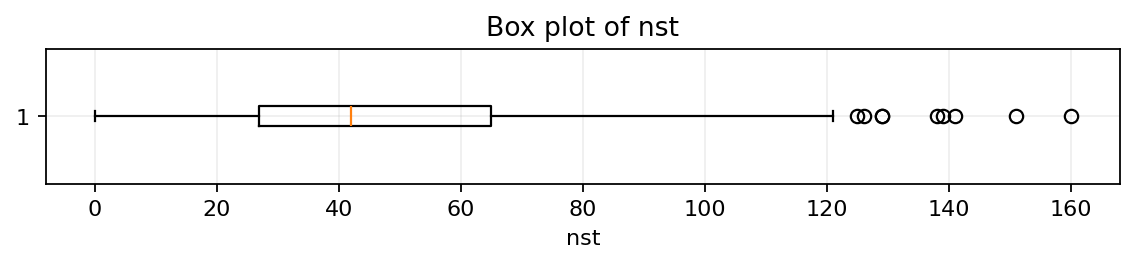

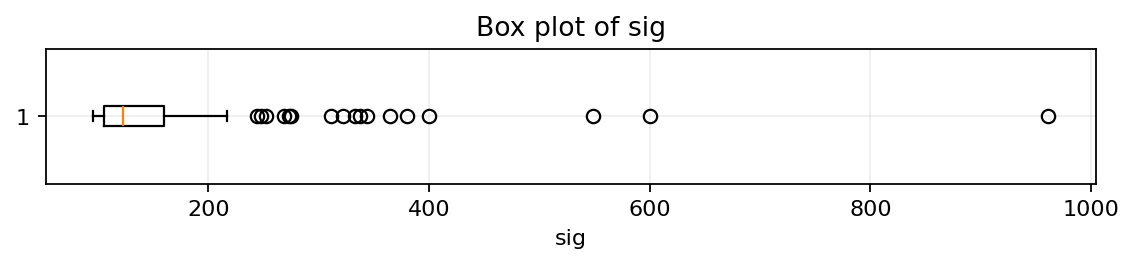

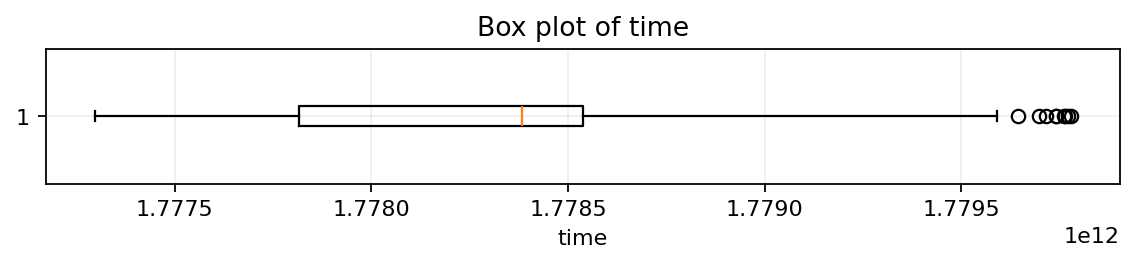

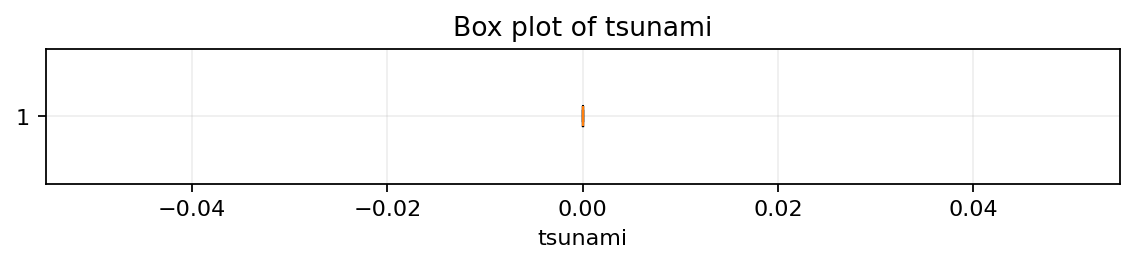

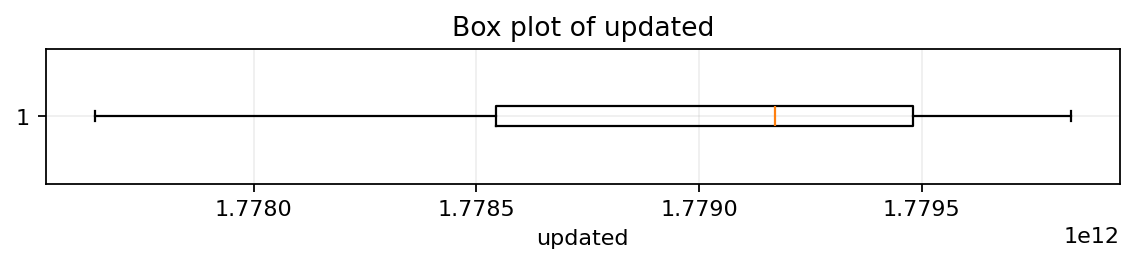

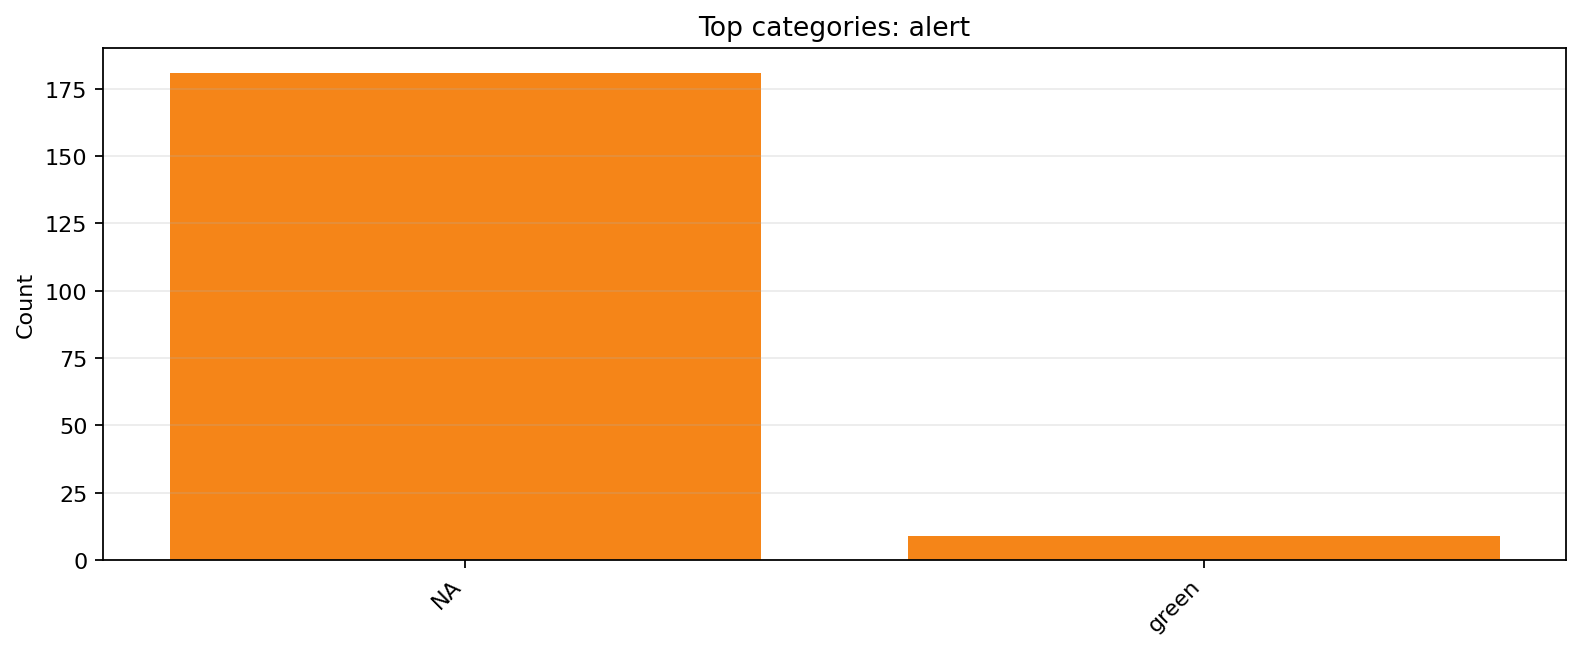

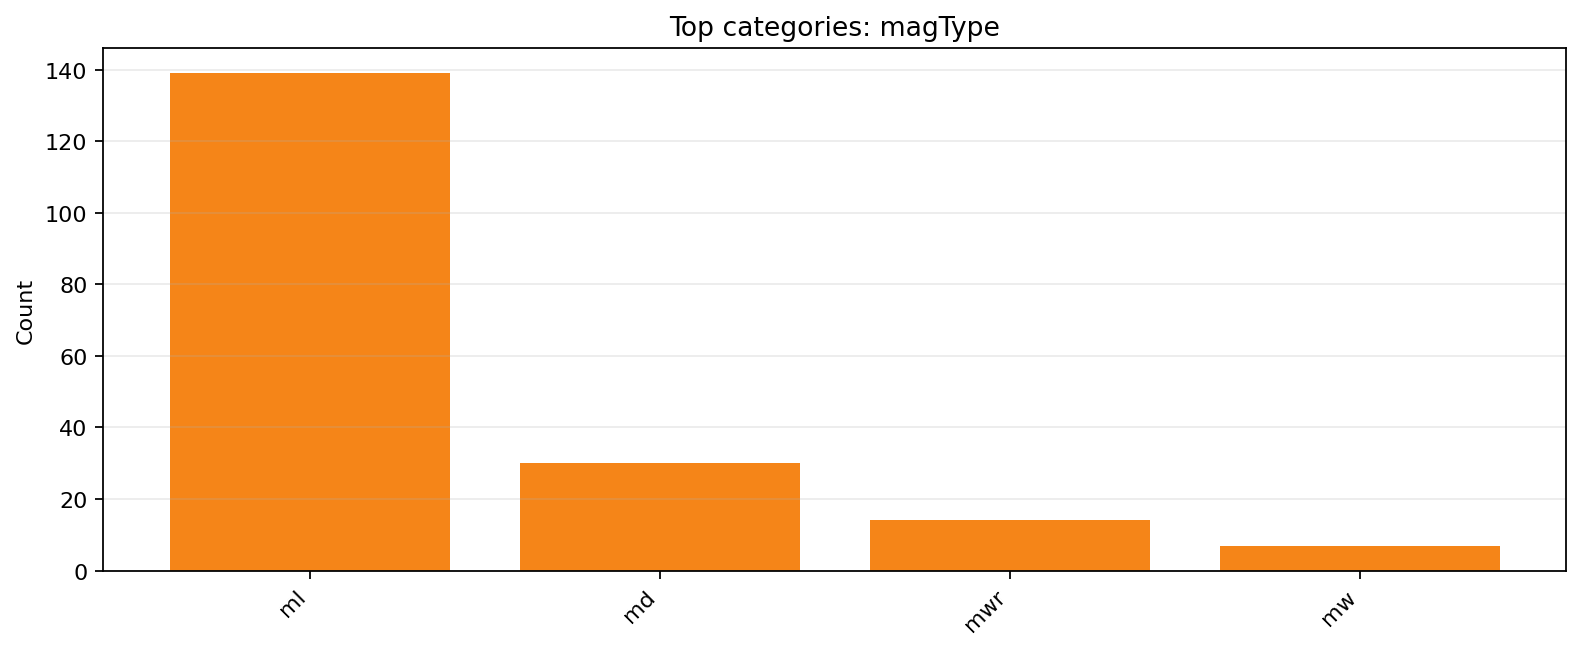

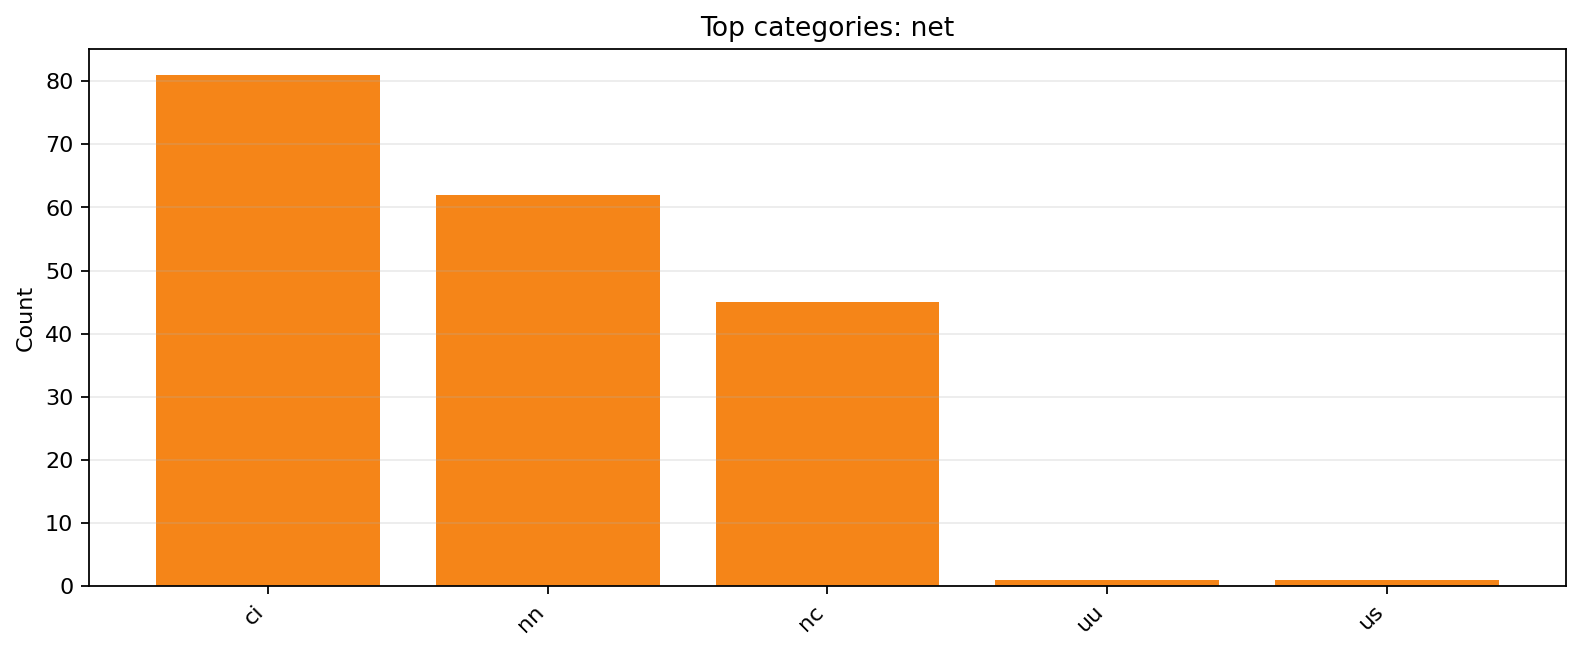

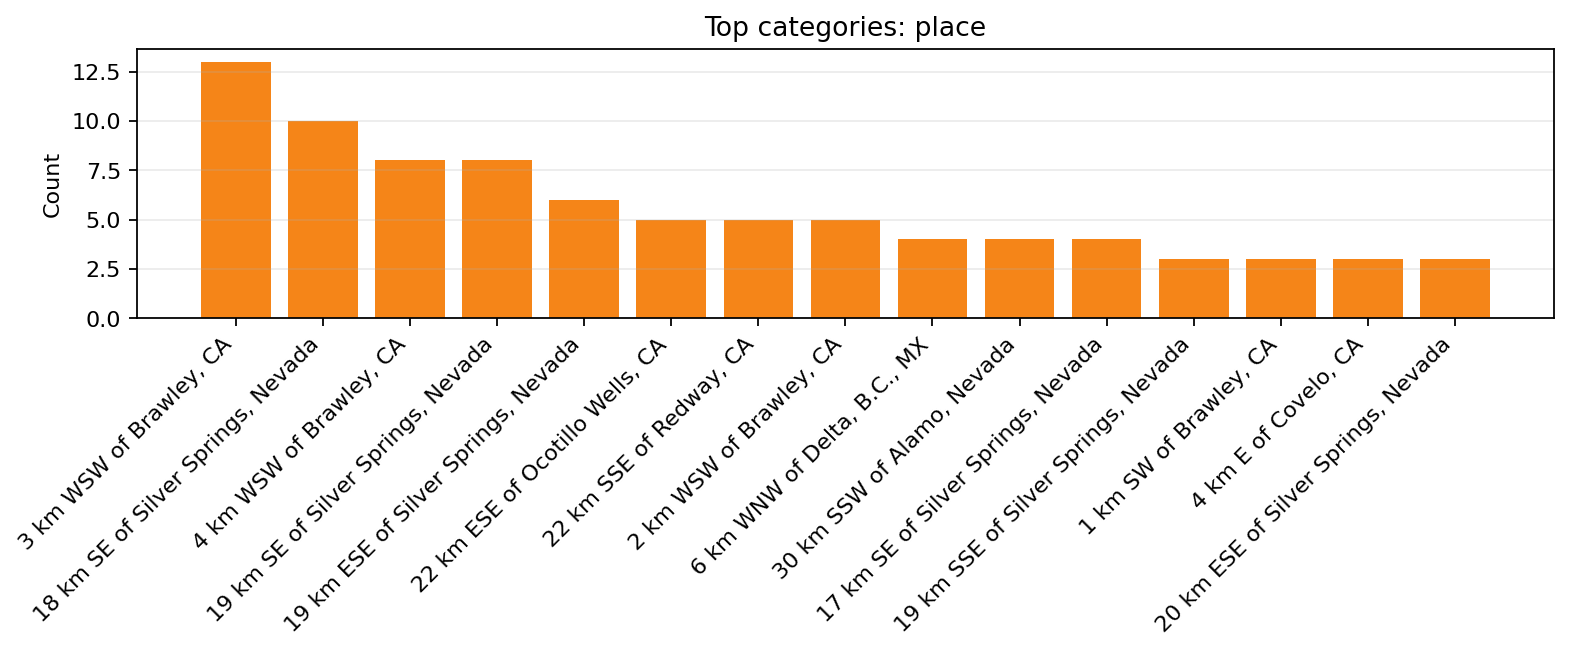

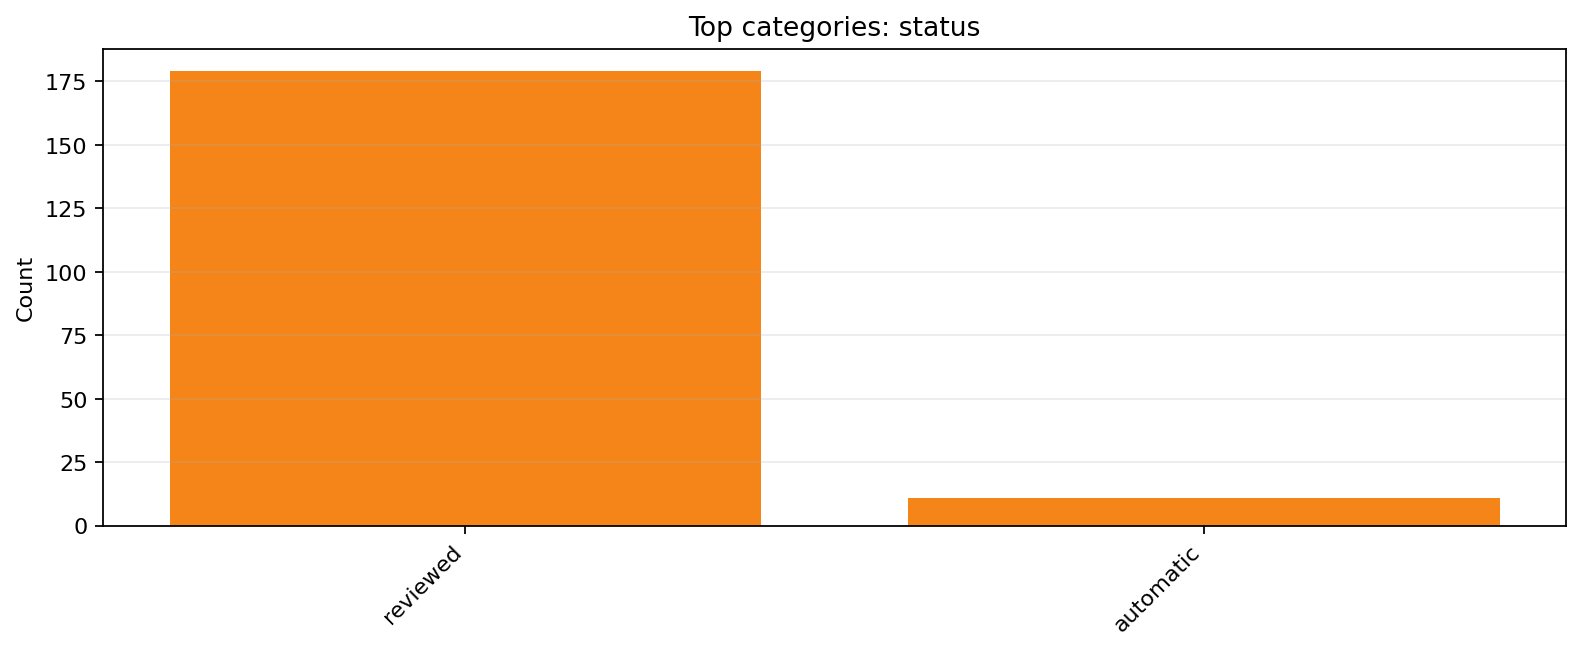

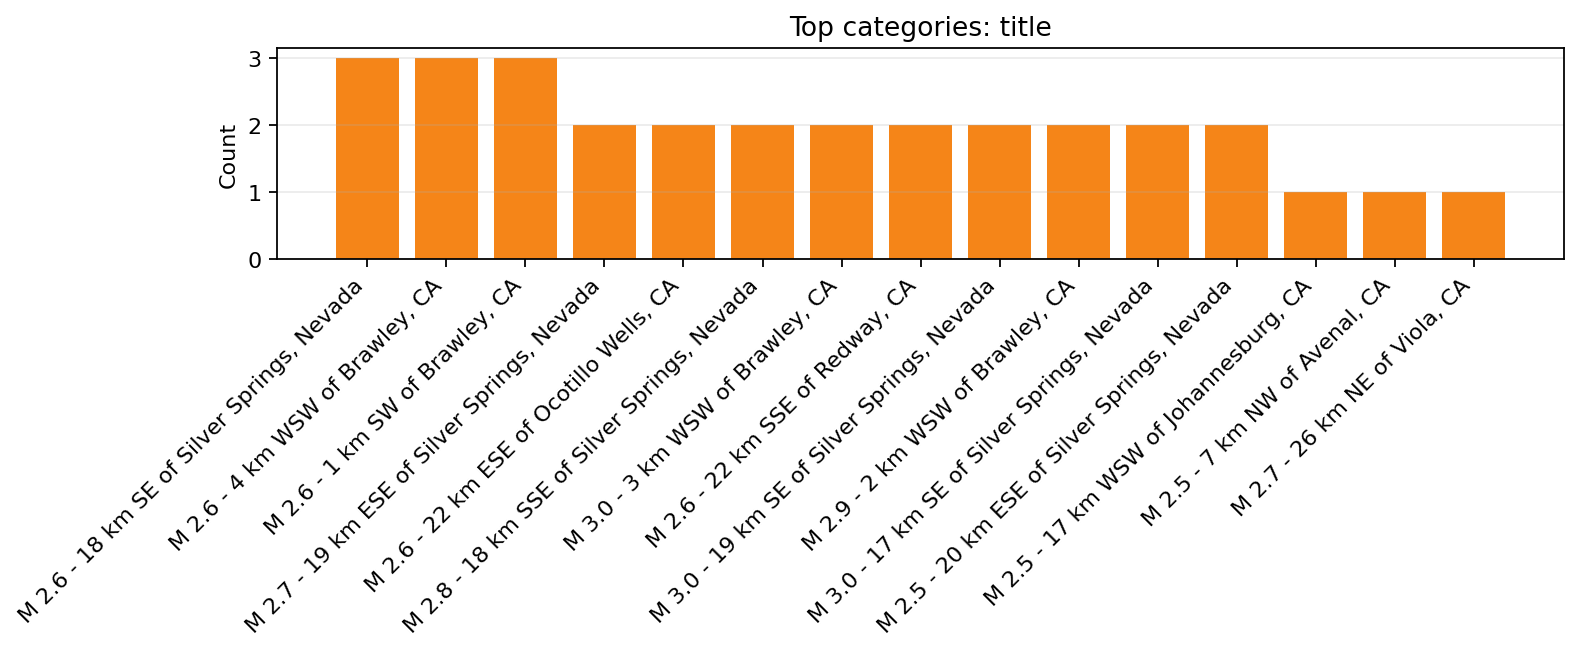

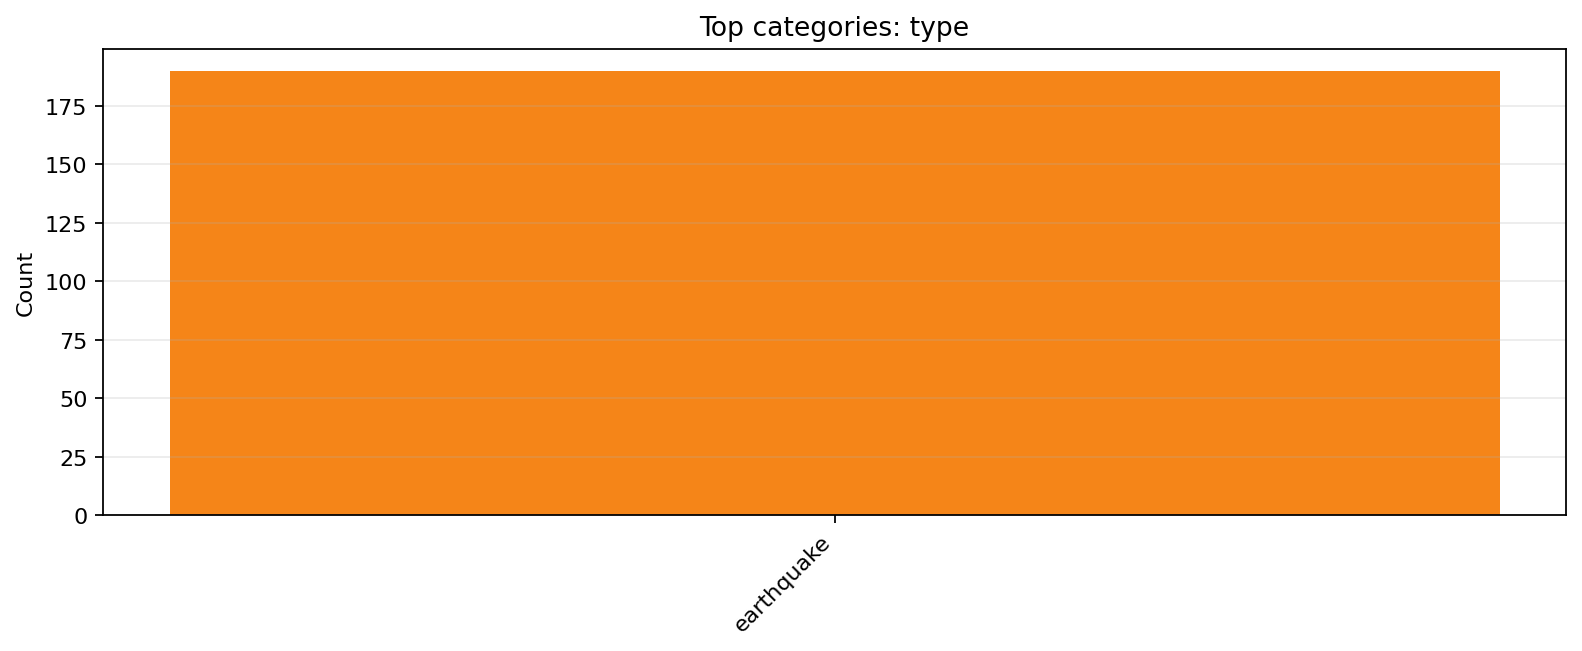

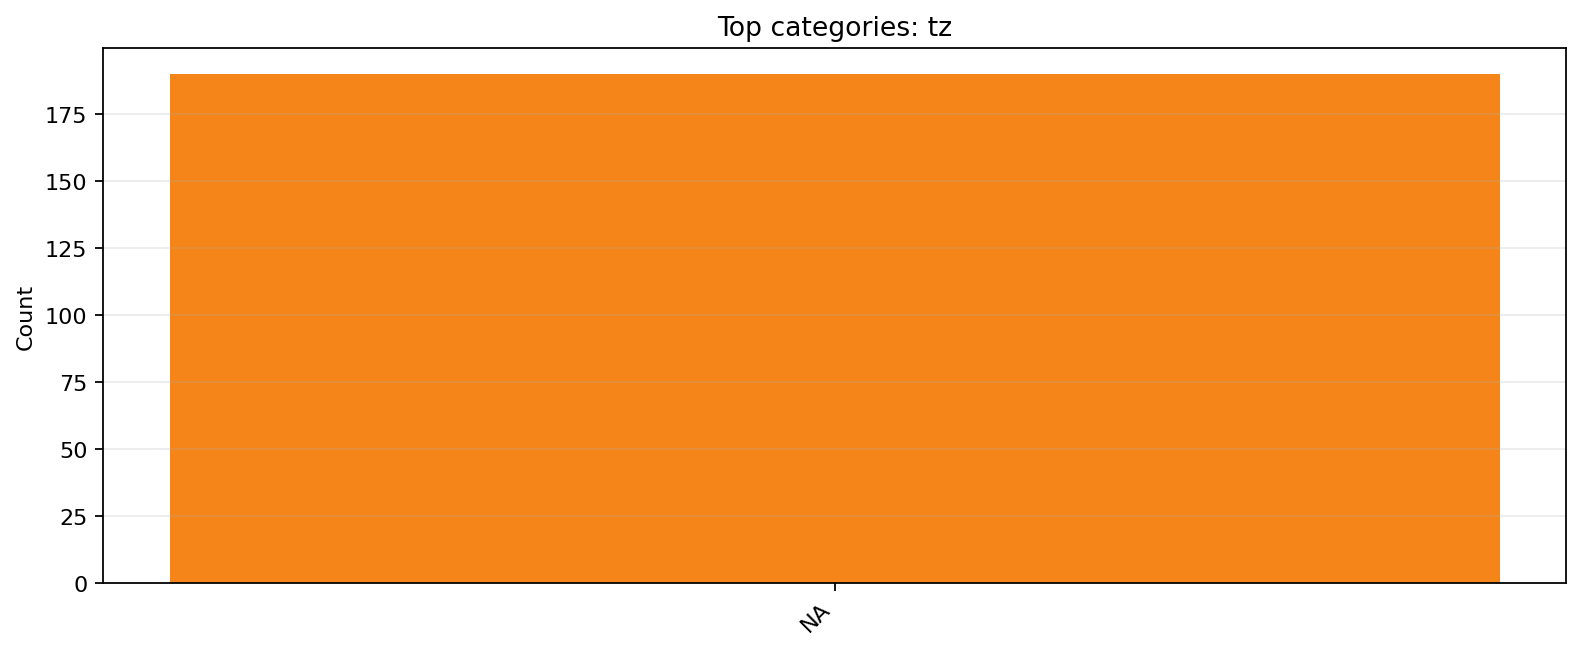

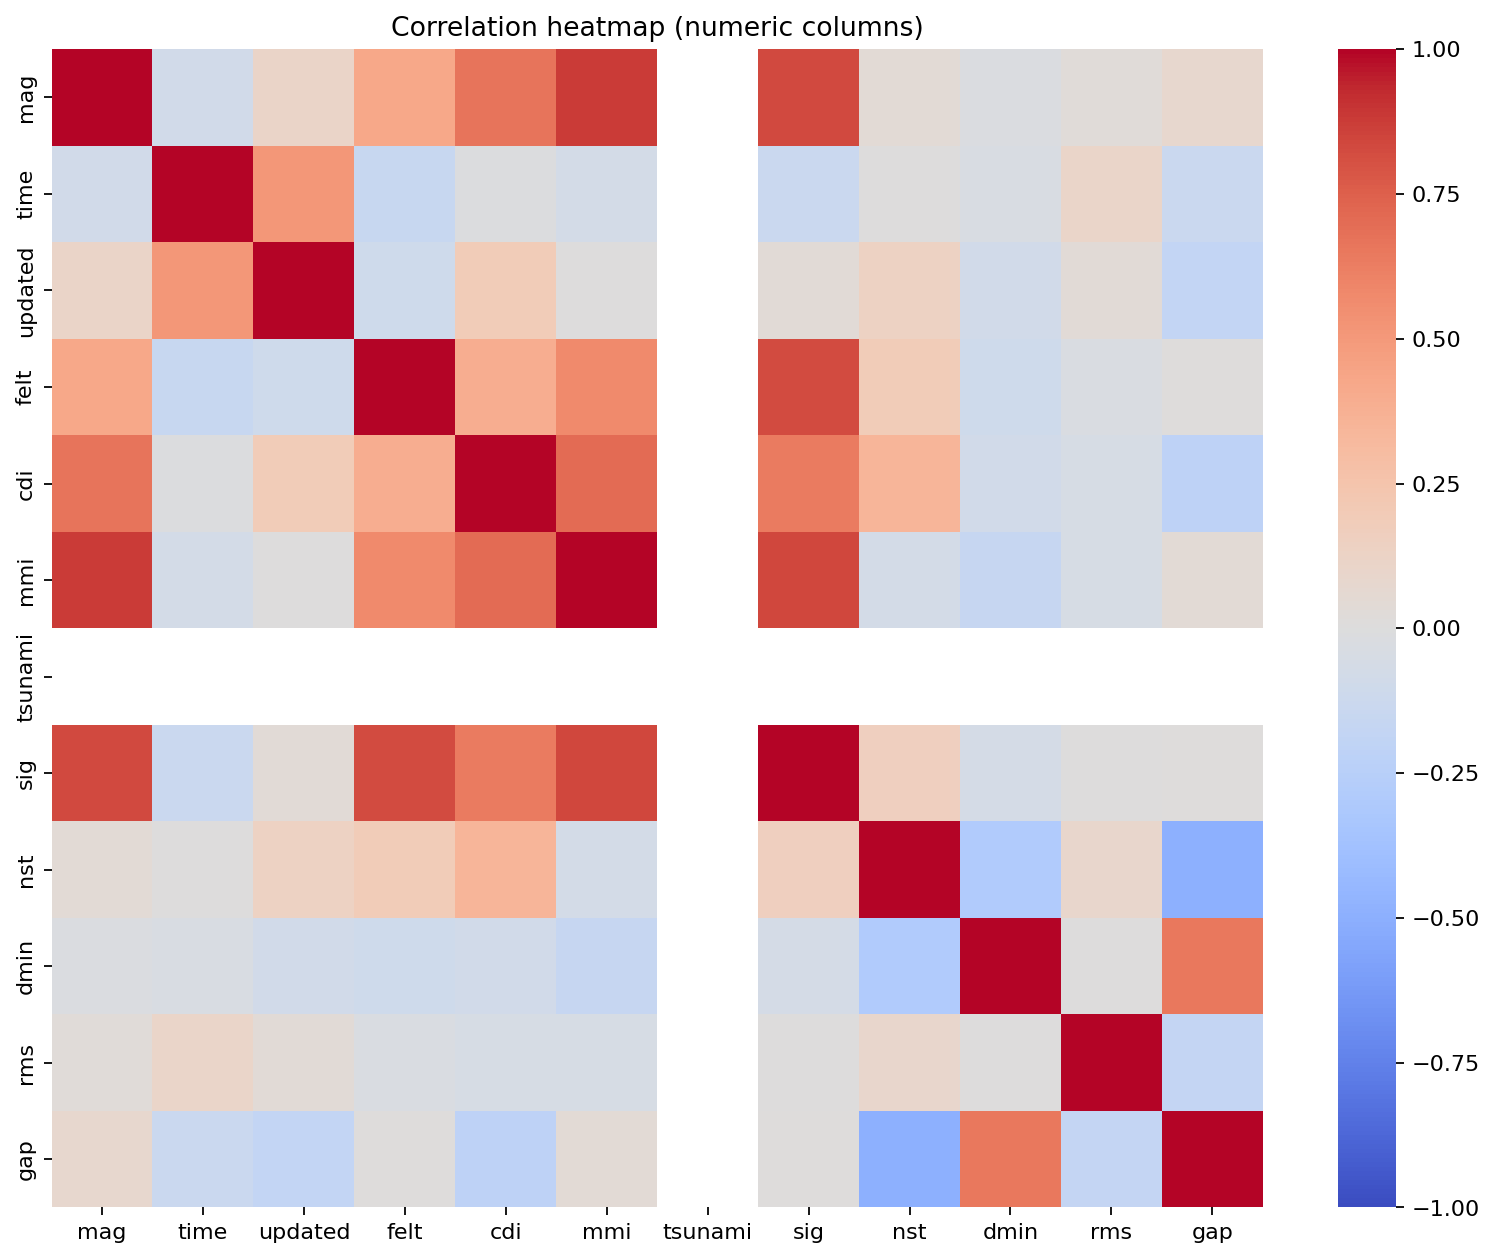

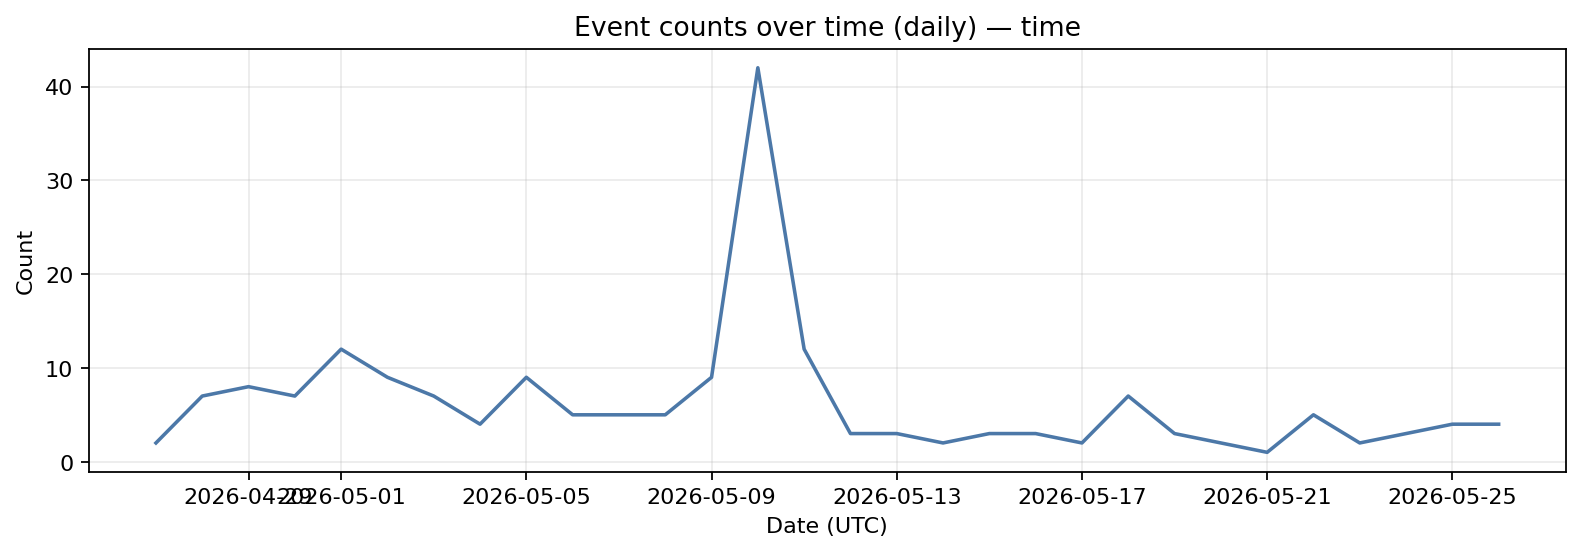

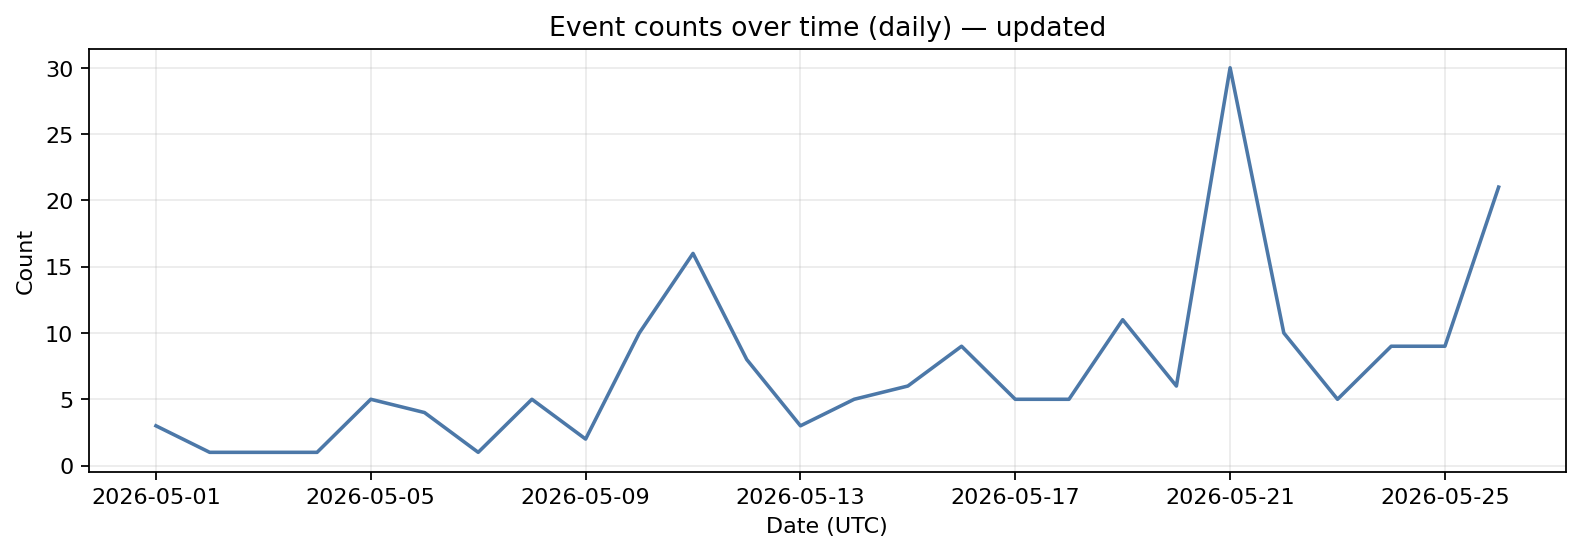

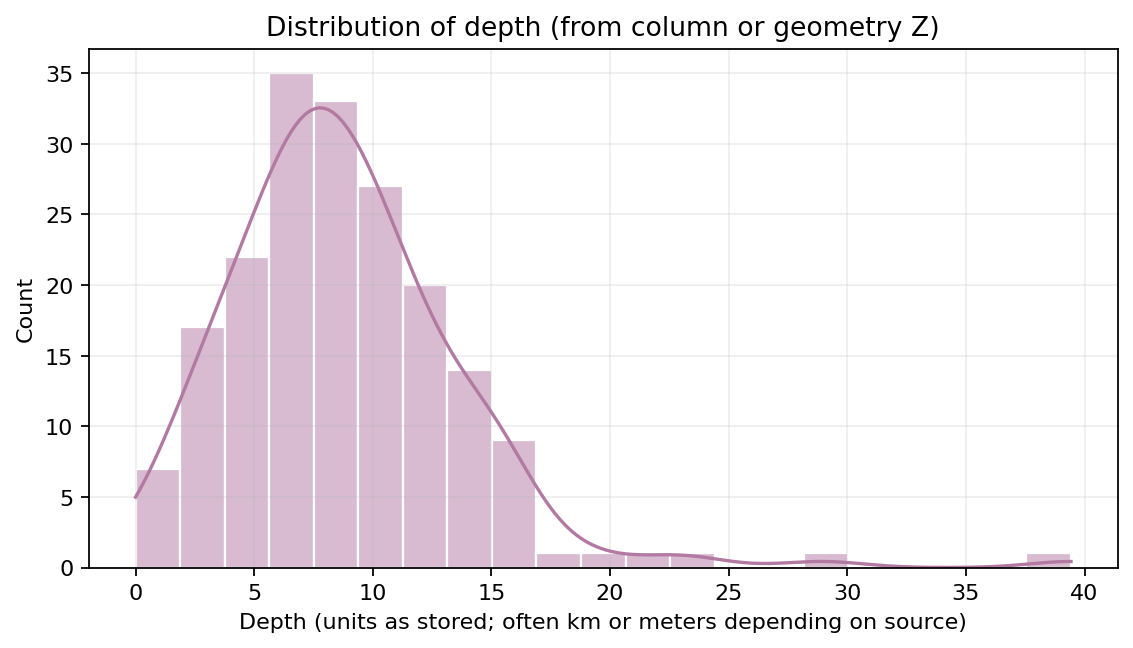

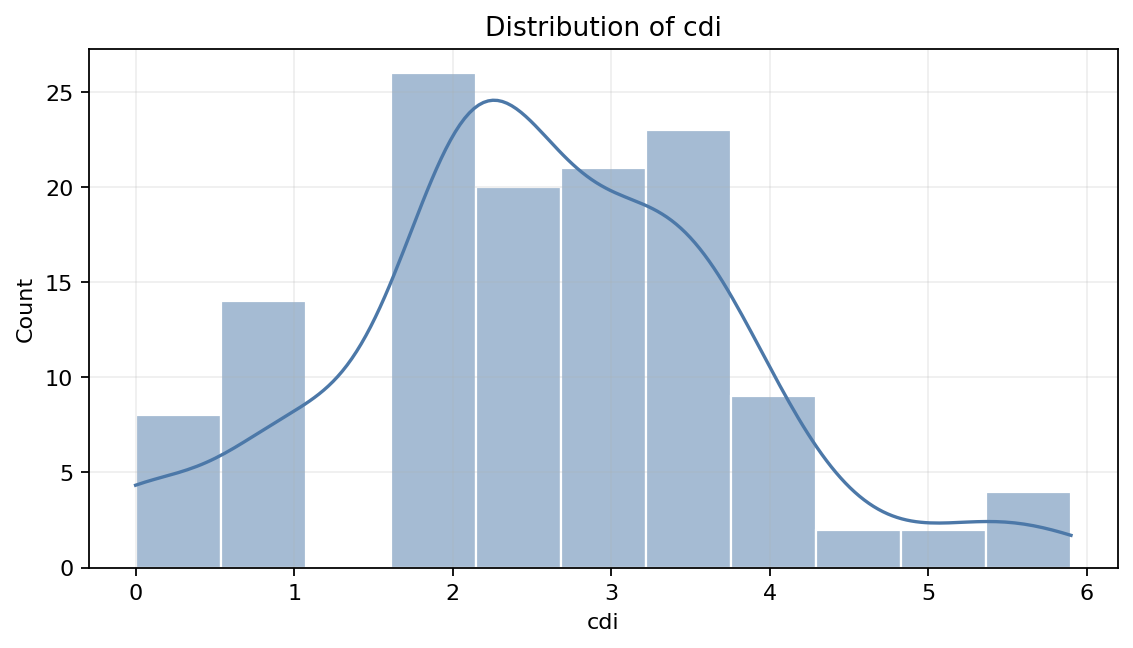

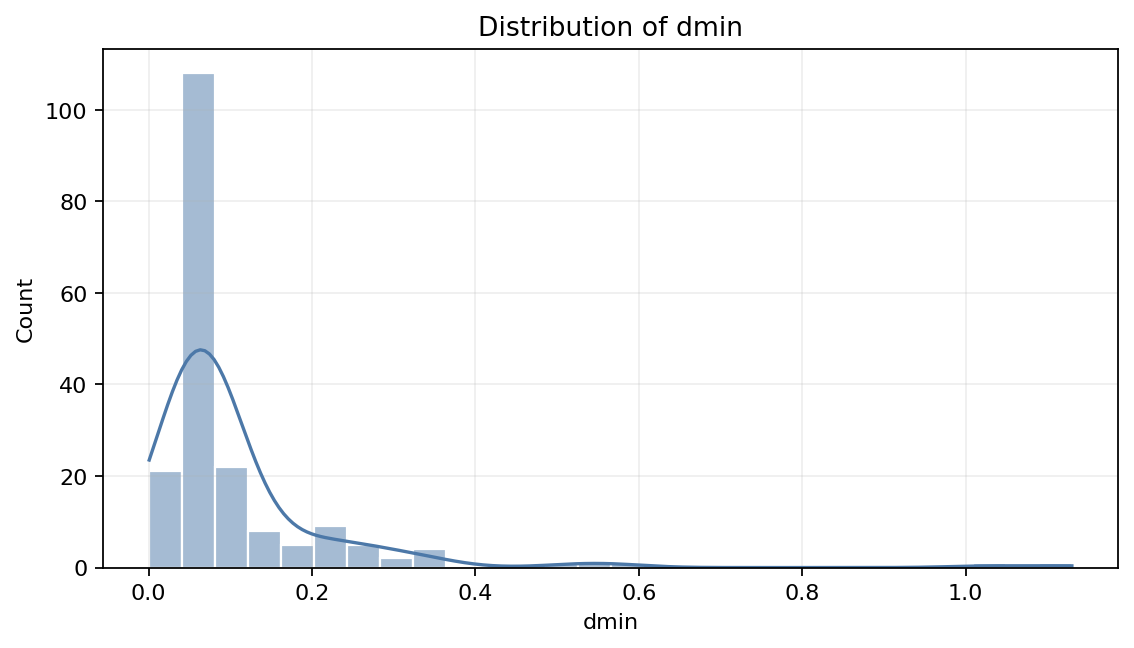

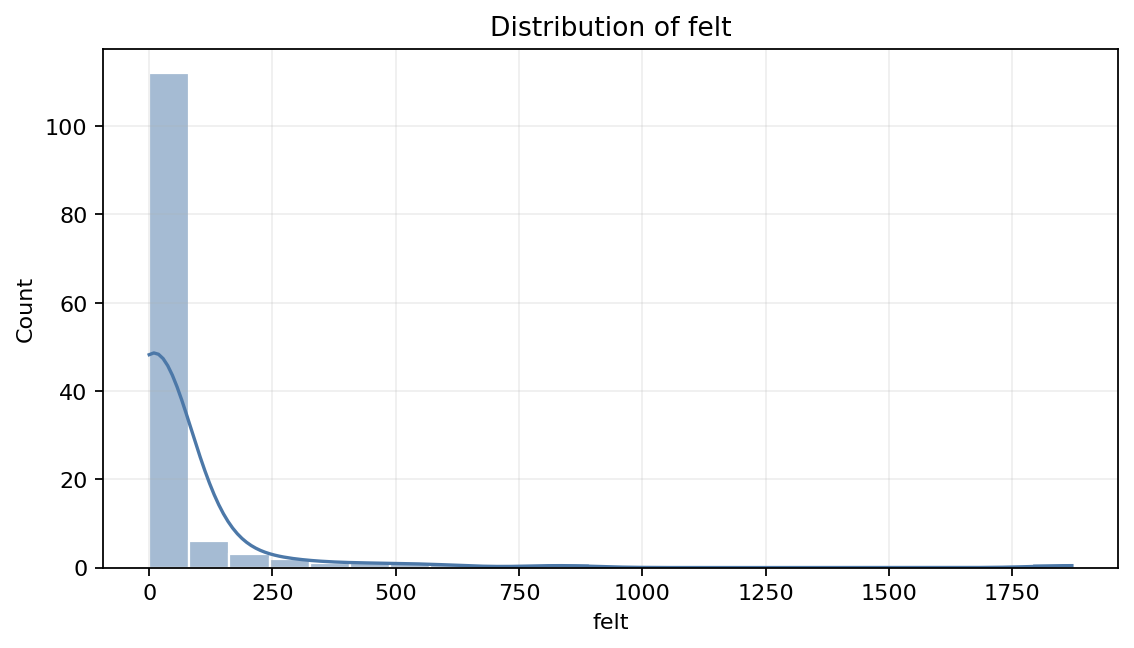

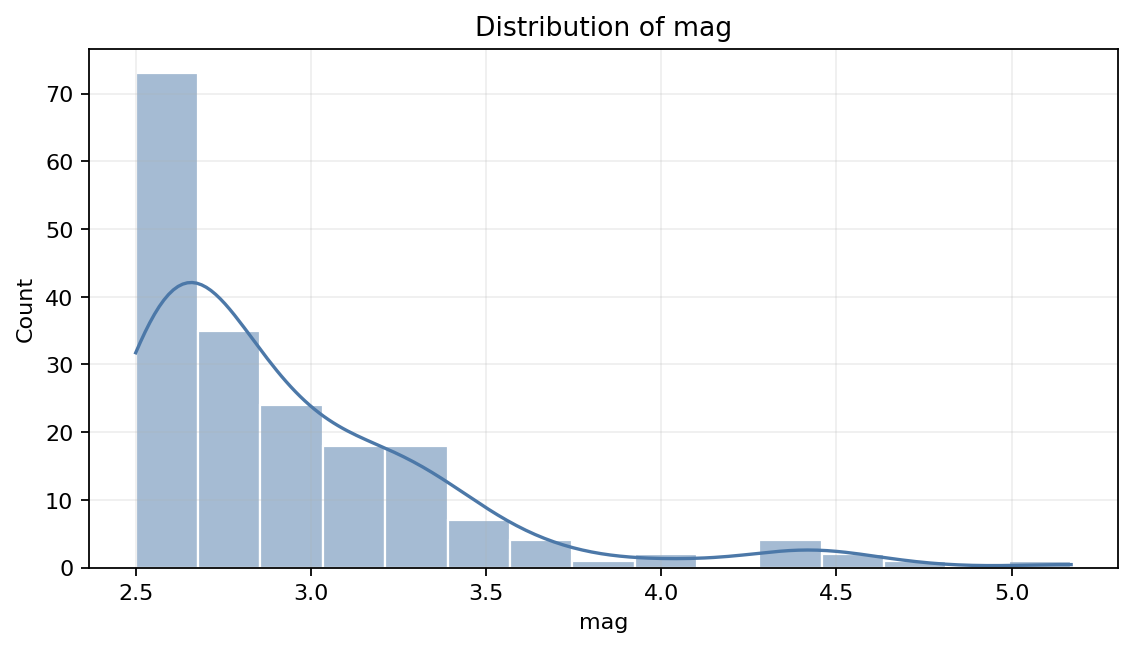

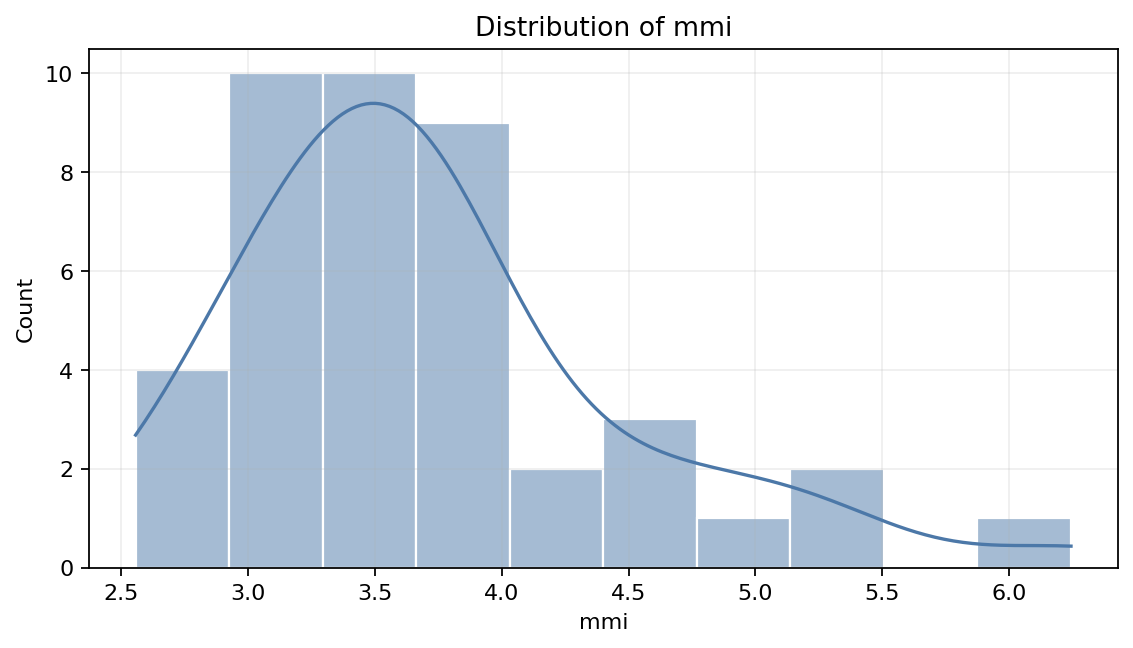

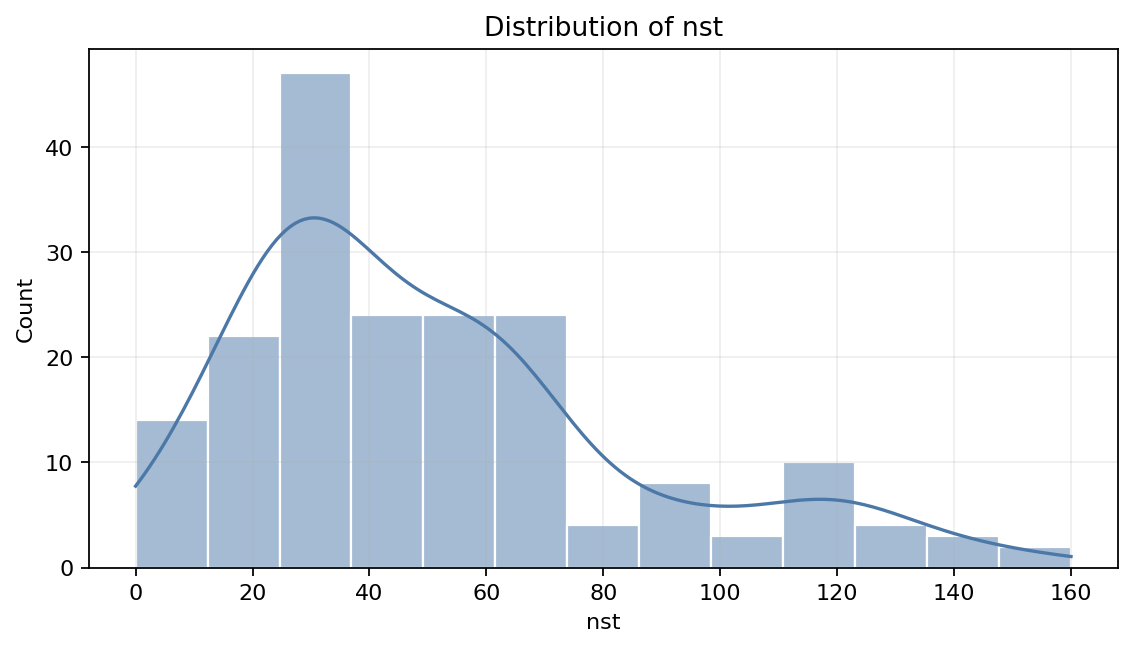

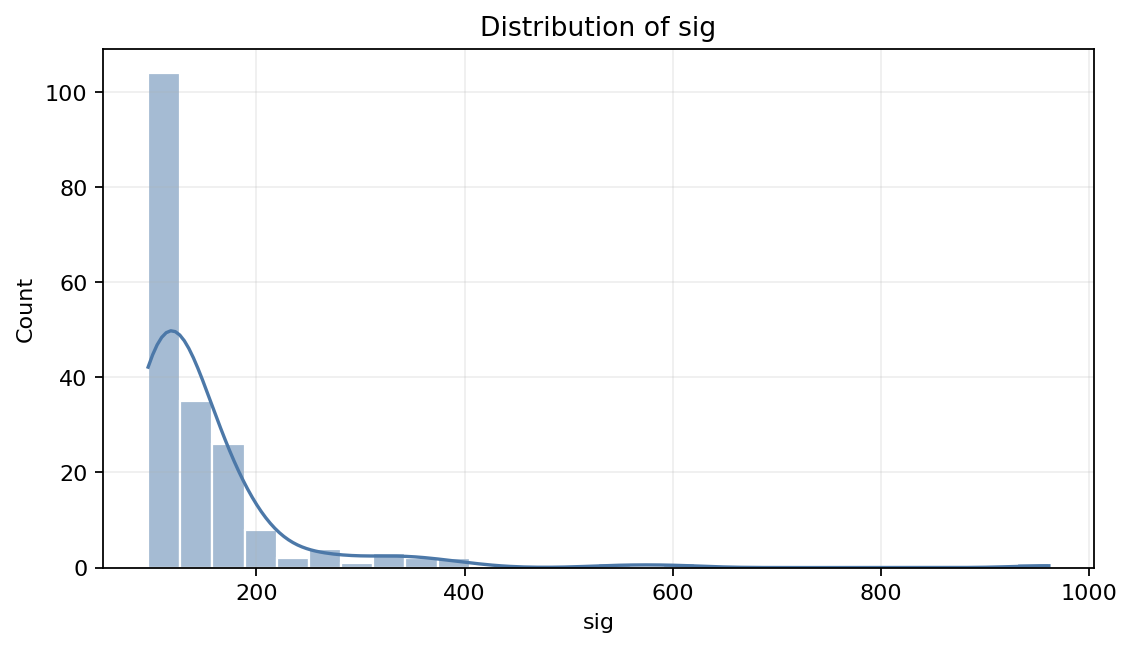

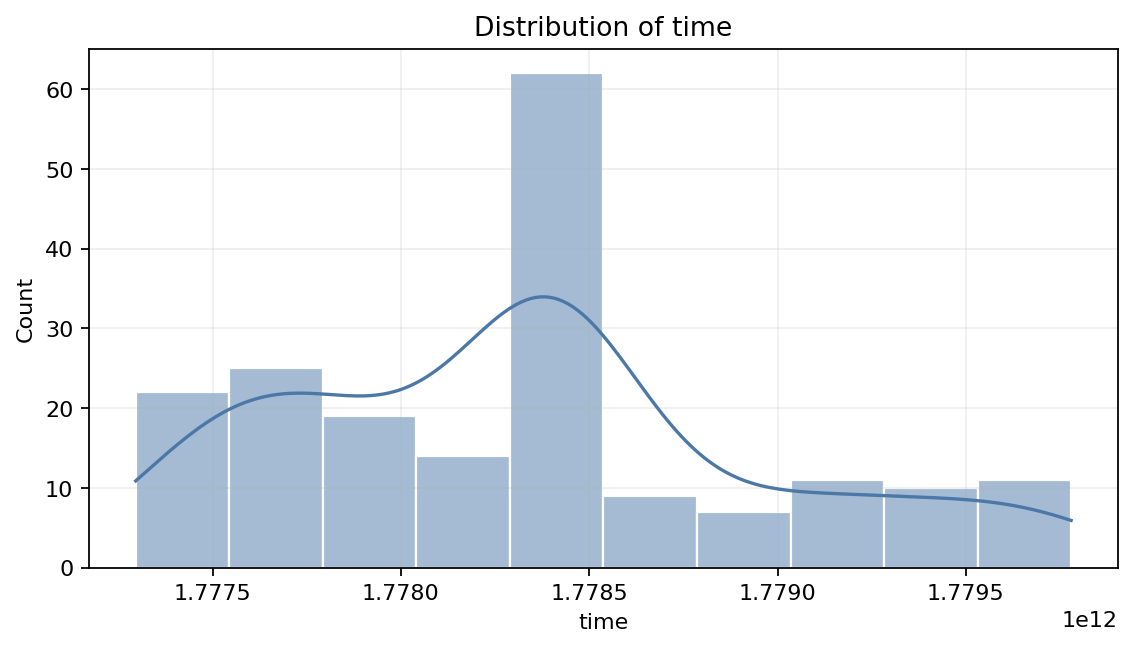

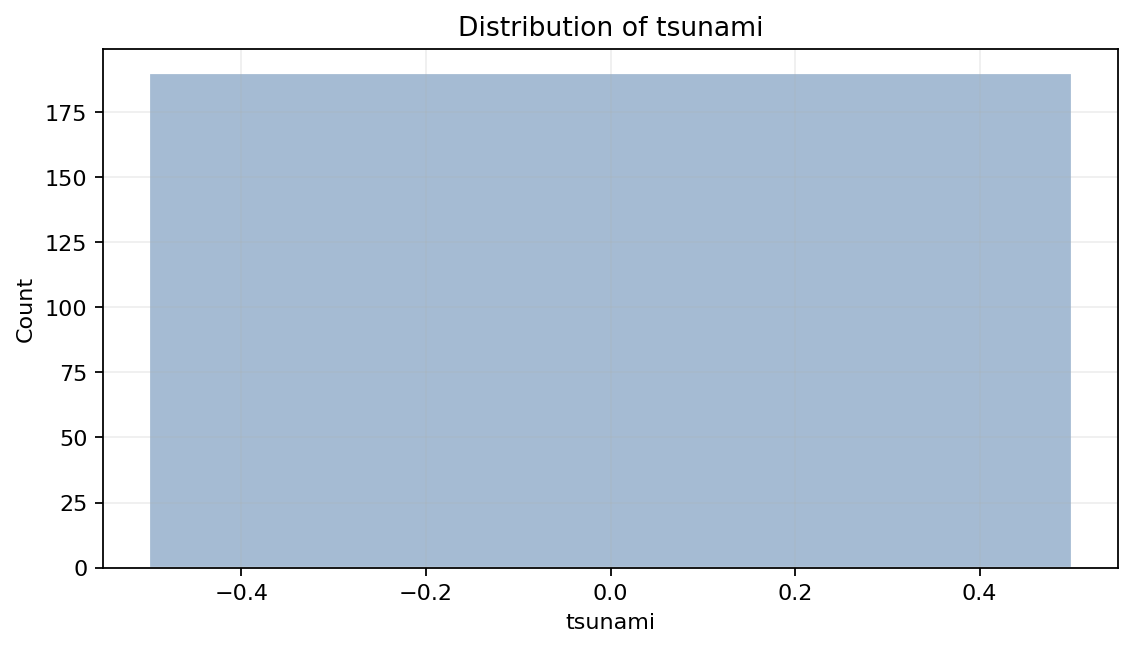

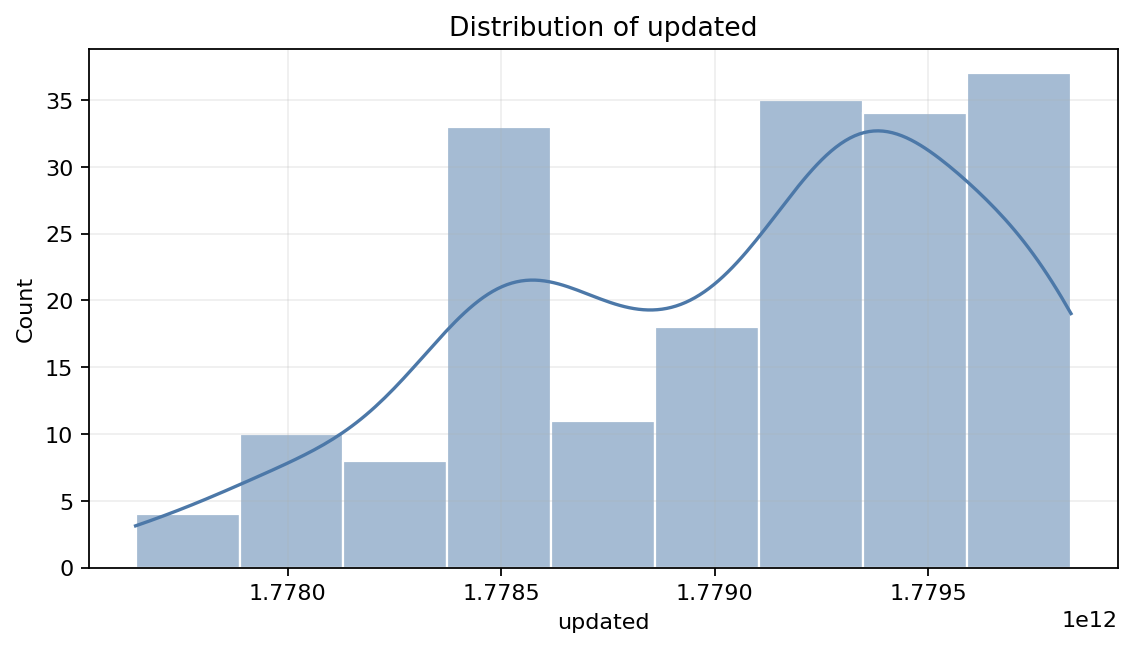

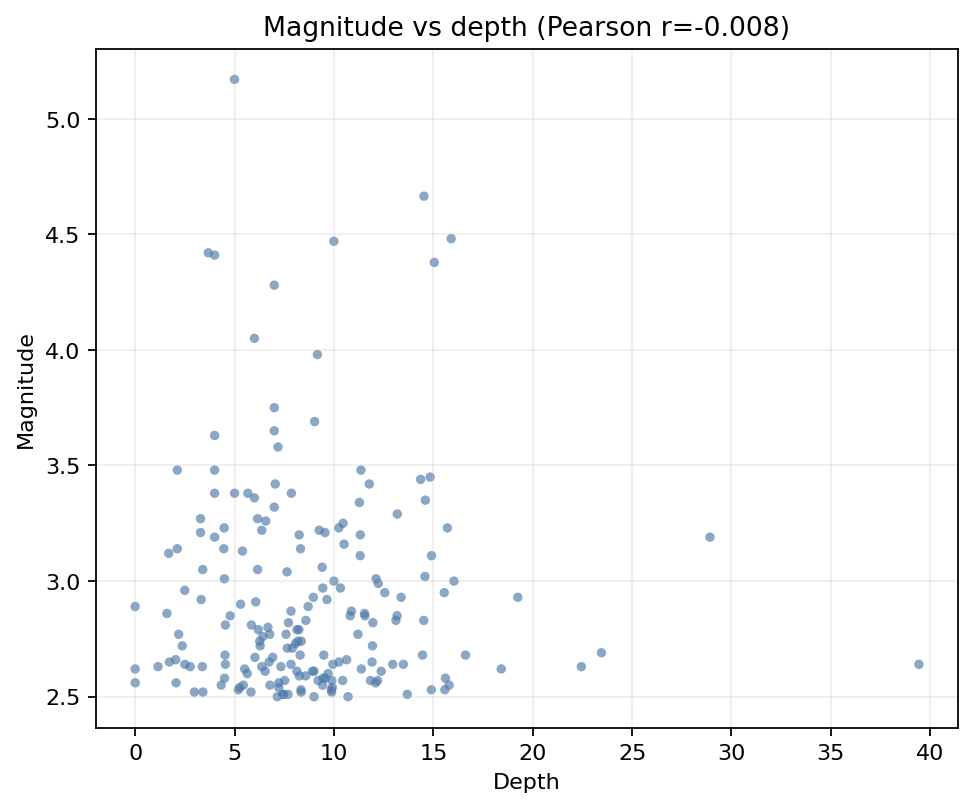

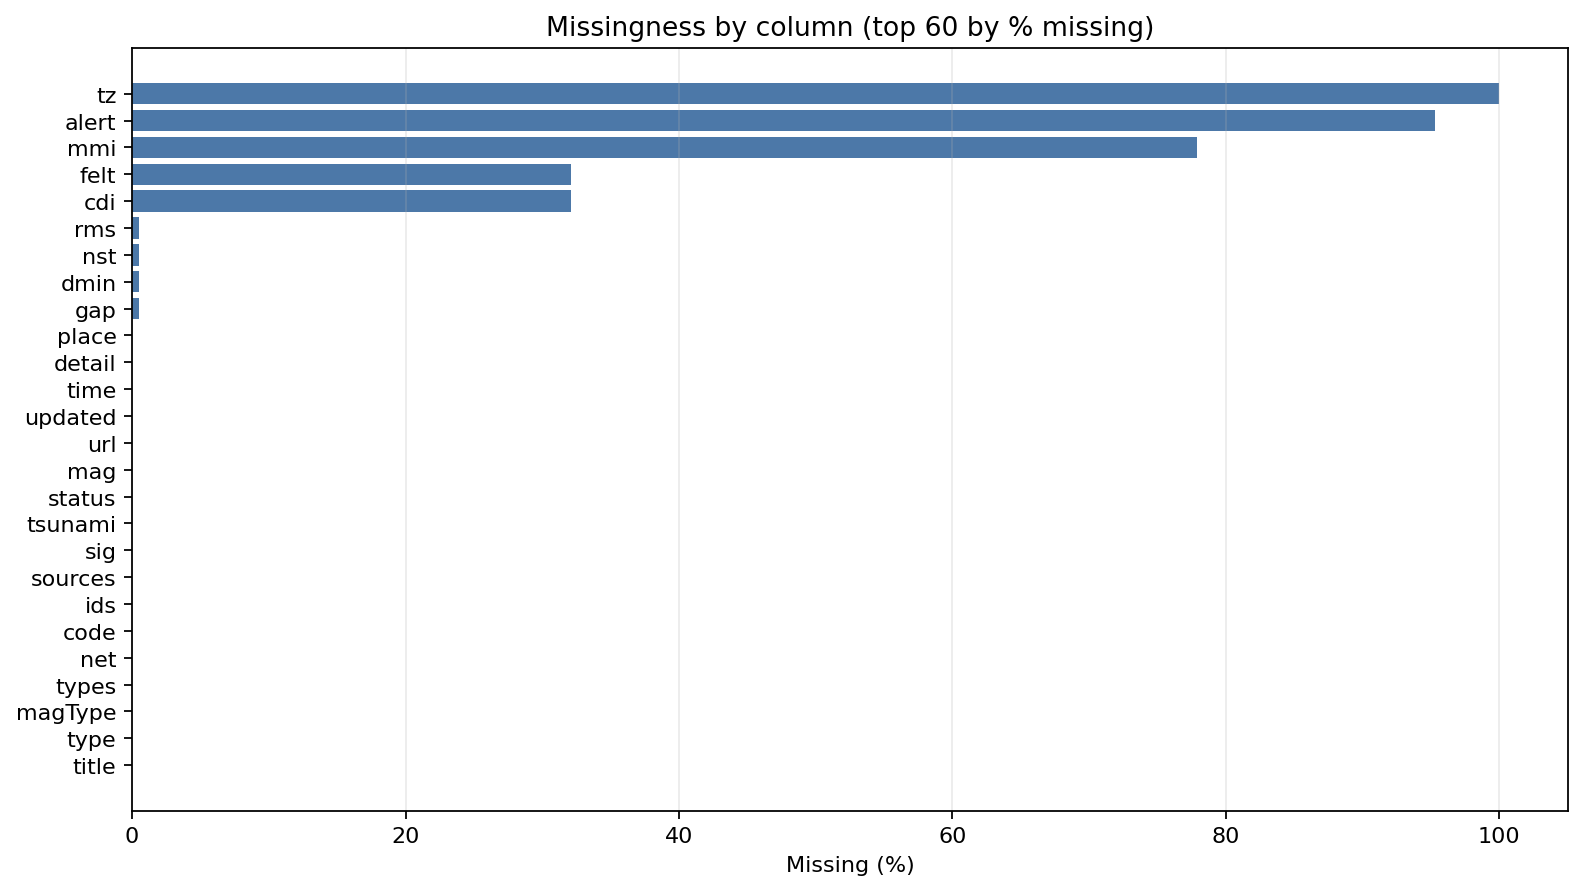

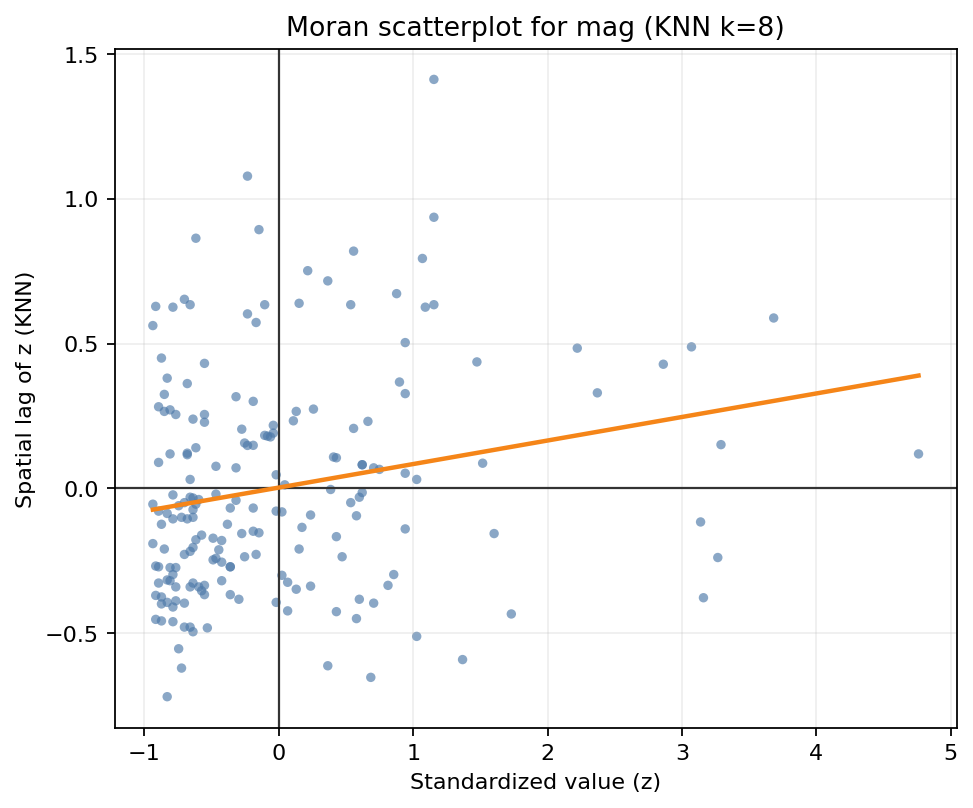

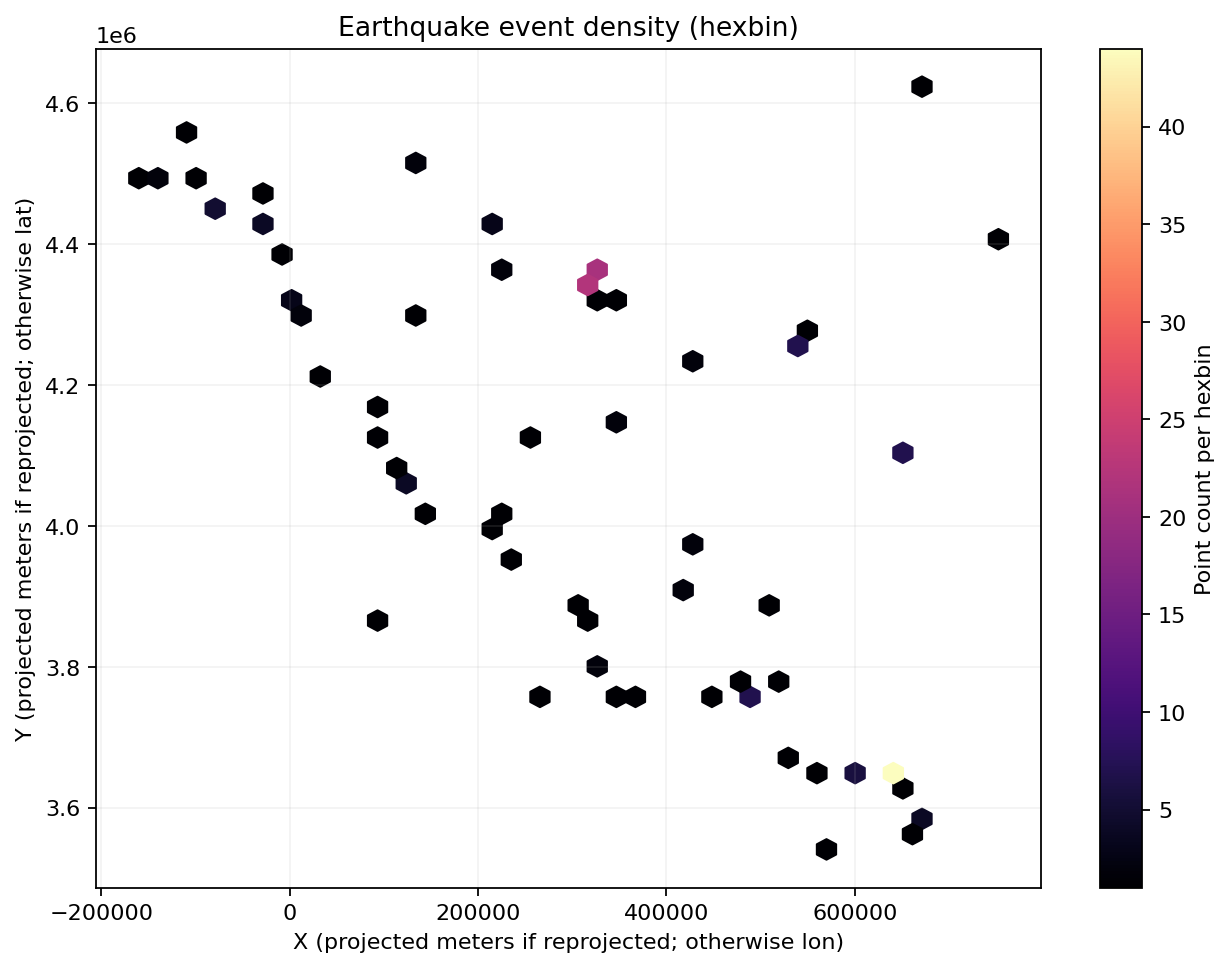

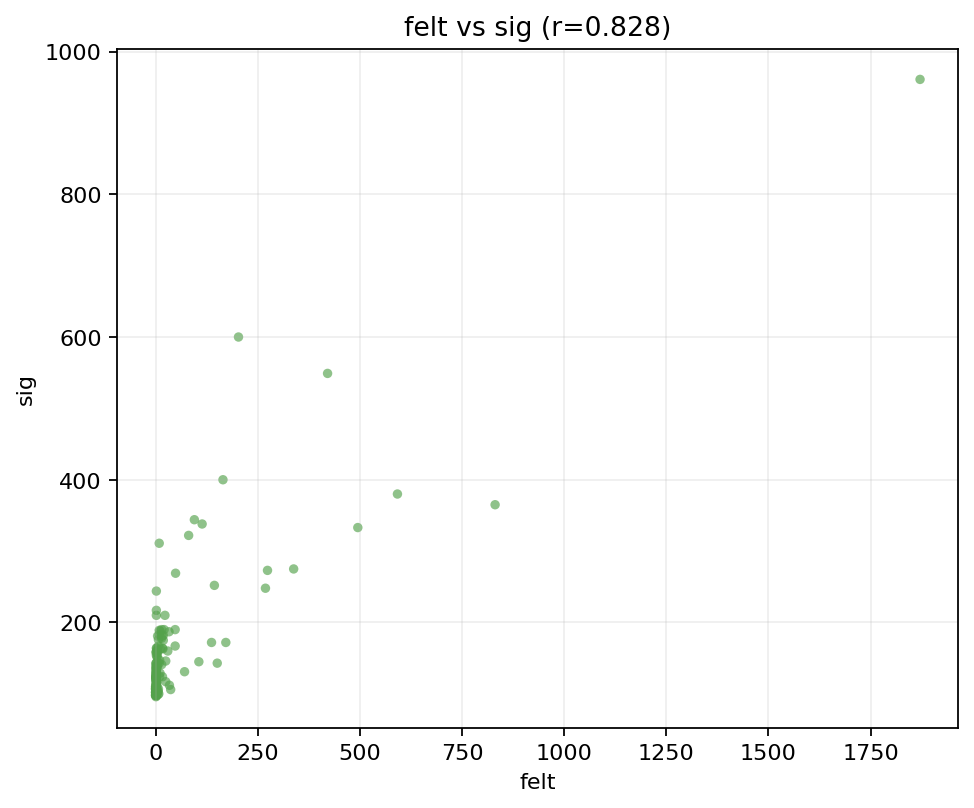

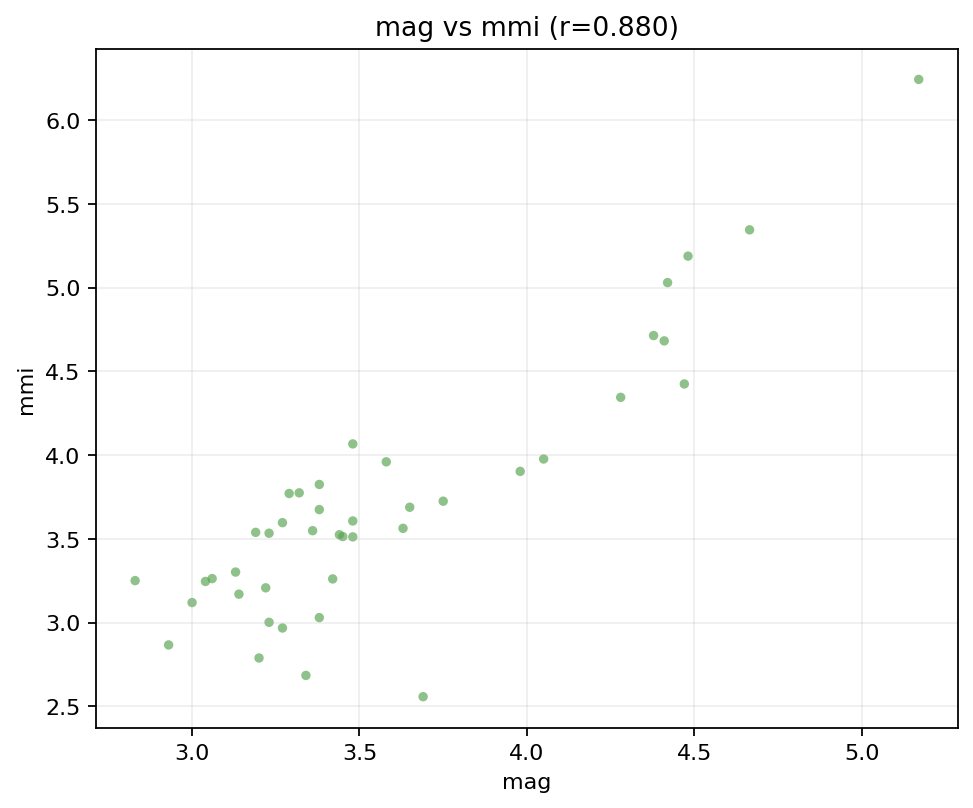

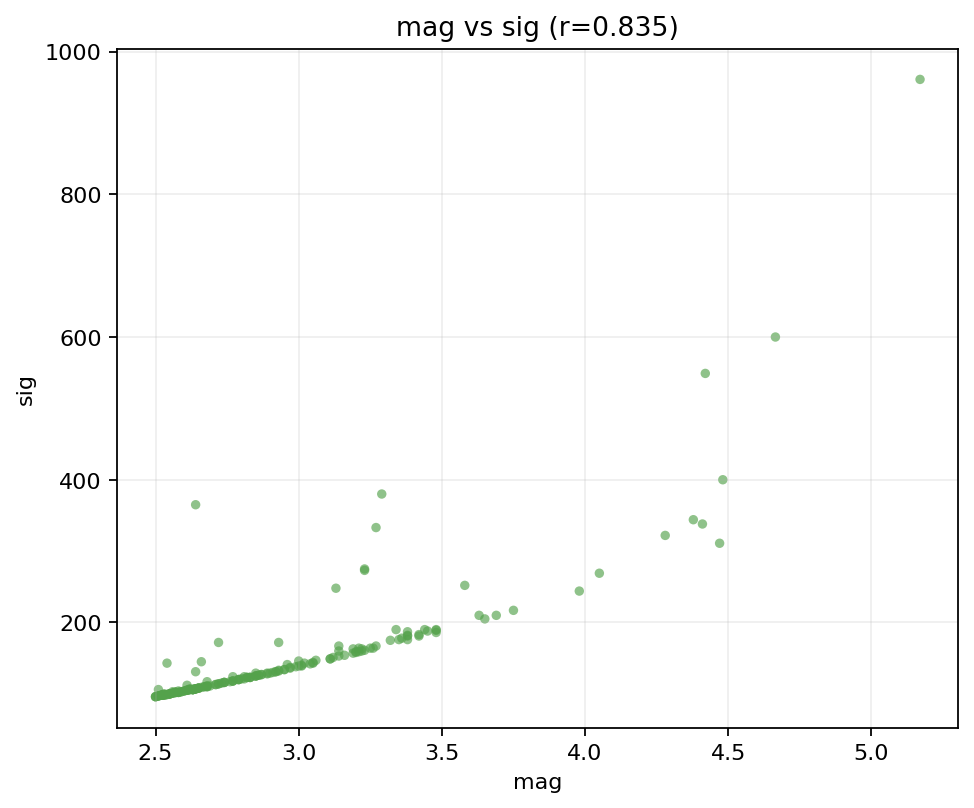

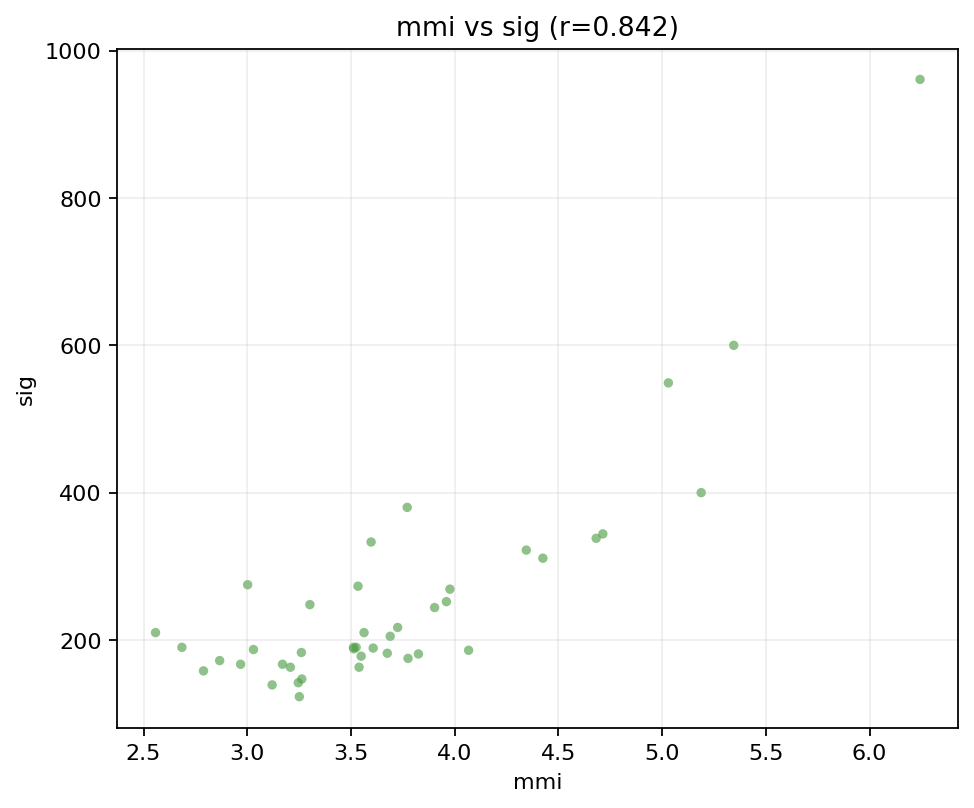

In [8]:
display_visual_artifacts(esda_result)